# Transfer Learning With VGG-19

This notebook uses a pretrained VGG-19 model as a fixed feature extractor for cats vs dogs.

## Notes Before Running

- The first run may download pretrained VGG-19 weights (~550 MB).
- VGG-19 expects 224×224 inputs — the same size used during ImageNet pretraining.
- The same folder structure from the previous notebook is expected.


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

seed = 42
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
data_dir = Path("cats_dogs_subset")
train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

image_size = 224
batch_size = 32
num_workers = 0
learning_rate = 1e-3
num_epochs = 5

limit_train_per_class = 750
limit_val_per_class = 200
limit_test_per_class = 200

for split_dir in (train_dir, val_dir, test_dir):
    if not split_dir.exists():
        raise FileNotFoundError(
            f"Missing folder: {split_dir}\n"
            "Create train/val/test folders with one subfolder per class before running the notebook."
        )


In [3]:
# These are the mean and std used to normalise ImageNet during VGG-19 pretraining.
# We must apply the same normalisation so our inputs match what the frozen layers expect.
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


In [4]:
def make_balanced_subset(dataset, limit_per_class=None):
    if limit_per_class is None:
        return dataset

    selected_indices = []
    counts = {class_idx: 0 for class_idx in range(len(dataset.classes))}

    for index, (_, class_idx) in enumerate(dataset.samples):
        if counts[class_idx] < limit_per_class:
            selected_indices.append(index)
            counts[class_idx] += 1

        if all(count == limit_per_class for count in counts.values()):
            break

    return Subset(dataset, selected_indices)


full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
full_val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
full_test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

train_dataset = make_balanced_subset(full_train_dataset, limit_train_per_class)
val_dataset = make_balanced_subset(full_val_dataset, limit_val_per_class)
test_dataset = make_balanced_subset(full_test_dataset, limit_test_per_class)

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = full_train_dataset.classes
print(f"Classes: {class_names}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['cats', 'dogs']
Training samples: 1500
Validation samples: 400
Test samples: 400


## Pretrained VGG-19 as Feature Extractor

VGG-19 was trained on ImageNet — 1.2 million images across 1000 classes — using 224×224 RGB inputs.
Its 16 convolutional layers learned a hierarchy of general visual features: edges → textures → parts → objects.
These features transfer well to new tasks because natural images share low-level structure regardless of the specific classes.

We will:
- load VGG-19 with pretrained ImageNet weights
- freeze the convolutional feature extractor (`self.features`) — no gradients, no weight updates
- train only a small binary classifier head for the cats vs dogs task

Because only the head is trained, the model converges in very few epochs compared to training from scratch.


In [5]:
weights = models.VGG19_Weights.DEFAULT

class VGG19Binary(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.vgg19(weights=weights)
        self.features = backbone.features

        for parameter in self.features.parameters():    # Freeze the pretrained layers
            parameter.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d((4, 4))    #adaptive pooling to get a fixed-size output regardless of input size
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = VGG19Binary().to(device)
print(model)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\larin/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100.0%


VGG19Binary(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 

In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=learning_rate)

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = (outputs >= 0.5).float()
        total_loss += loss.item() * images.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += images.size(0)

    average_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return average_loss, accuracy

In [8]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, trainloader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, valloader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
    )

Epoch 01/5 | train loss: 0.1199 | train acc: 0.9453 | val loss: 0.0431 | val acc: 0.9825
Epoch 02/5 | train loss: 0.0407 | train acc: 0.9873 | val loss: 0.0308 | val acc: 0.9850
Epoch 03/5 | train loss: 0.0136 | train acc: 0.9933 | val loss: 0.0855 | val acc: 0.9775
Epoch 04/5 | train loss: 0.0127 | train acc: 0.9960 | val loss: 0.0248 | val acc: 0.9900
Epoch 05/5 | train loss: 0.0080 | train acc: 0.9987 | val loss: 0.0188 | val acc: 0.9875


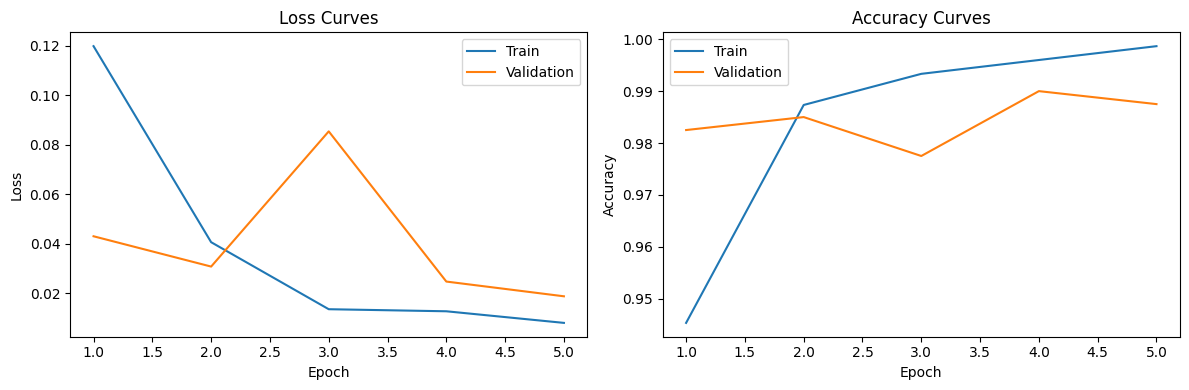

In [9]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_acc = run_epoch(model, testloader, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.0508
Test accuracy: 0.9825


## Further Reading

VGG-19 was introduced in:

> Simonyan, K., & Zisserman, A. (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. arXiv:1409.1556.
> https://arxiv.org/abs/1409.1556

The paper is short and readable — it focuses on the effect of network depth using very small (3×3) convolution filters, and it includes ablation experiments comparing VGG-11 through VGG-19.

The model was trained on the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2012 dataset:
https://www.image-net.org/challenges/LSVRC/2012/


## How VGG-19 Was Trained

**The dataset — ImageNet ILSVRC**
- 1.2 million training images, 1000 categories (dogs, cats, cars, food, instruments, …)
- The challenge: given an image, predict the correct class out of 1000
- This forced the network to learn rich, general visual representations

**The architecture**
- 19 layers deep — very deep for 2014
- Key insight from the paper: use only small 3×3 conv filters throughout, instead of larger ones
- Why? Two stacked 3×3 convolutions cover the same receptive field as one 5×5, but with fewer parameters and an extra non-linearity
- Ends with 3 fully connected layers → softmax over 1000 classes

**The training**
- SGD with momentum, weight decay, and a manually tuned learning rate schedule
- Trained on 4 GPUs for 2–3 weeks — this was expensive
- Data augmentation: random crops, horizontal flips, color jitter

**What the layers learned**

| Layer depth | What it detects |
|---|---|
| Early layers | Edges, color gradients |
| Middle layers | Textures, patterns |
| Deeper layers | Object parts (eyes, fur, wheels) |
| Last layers | Full object concepts |

**Why this matters for transfer learning**

The first layers of VGG-19 are essentially an "edge detector" and "texture detector" — those are useful for *any* image task. By the time you get to the deeper layers, the network has already built useful representations for animals specifically (ImageNet has ~120 dog breeds alone).

So when we freeze `self.features` and just train the head, we're saying: *"trust the features VGG-19 already knows how to extract, and just learn to map them to our 2-class problem."* That's why 5 epochs is enough to get 98%.
